# Decision Tree Classifier

# Step 1 : Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# Step 2: Create dataset

In [4]:
data = {
    "Outlook": ["Sunny", "Sunny", "Overcast", "Rain", "Rain", "Overcast"],
    "Humidity": ["High", "High", "High", "Normal", "Normal", "Normal"],
    "Wind": ["Weak", "Strong", "Weak", "Weak", "Strong", "Strong"],
    "Play": ["No", "No", "Yes", "Yes", "No", "Yes"]
}

df = pd.DataFrame(data)
df

,Outlook,Humidity,Wind,Play
0,Sunny,High,Weak,No
1,Sunny,High,Strong,No
2,Overcast,High,Weak,Yes
3,Rain,Normal,Weak,Yes
4,Rain,Normal,Strong,No
5,Overcast,Normal,Strong,Yes


# encoded data

In [5]:
le=LabelEncoder()
for col in df.columns:
    df[col]=le.fit_transform(df[col])
df

,Outlook,Humidity,Wind,Play
0,2,0,1,0
1,2,0,0,0
2,0,0,1,1
3,1,1,1,1
4,1,1,0,0
5,0,1,0,1


In [6]:
X=df.drop("Play",axis=1)
y=df["Play"]

In [7]:
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.3, random_state=42)


In [8]:
X_train

,Outlook,Humidity,Wind
5,0,1,0
2,0,0,1
4,1,1,0
3,1,1,1


In [9]:
X_test

,Outlook,Humidity,Wind
0,2,0,1
1,2,0,0


In [10]:
model=DecisionTreeClassifier(criterion="entropy")
model.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy')

In [11]:
y_pre=model.predict(X_test)
print("prediction",y_pre)

prediction [1 0]


In [12]:
acc=accuracy_score(y_test,y_pre)
print("model accuracy",acc)

model accuracy 0.5


In [13]:
new_data=pd.DataFrame([[2,1,1]],columns=X.columns)
pre=model.predict(new_data)
print("New data prediction : ","Yes" if pre[0]==1 else "No")

New data prediction :  Yes


In [14]:
imp=model.feature_importances_
for feature, imp in zip(X.columns, imp):
    print(f"{feature}:{imp:.3}")

Outlook:0.616
Humidity:0.0
Wind:0.384


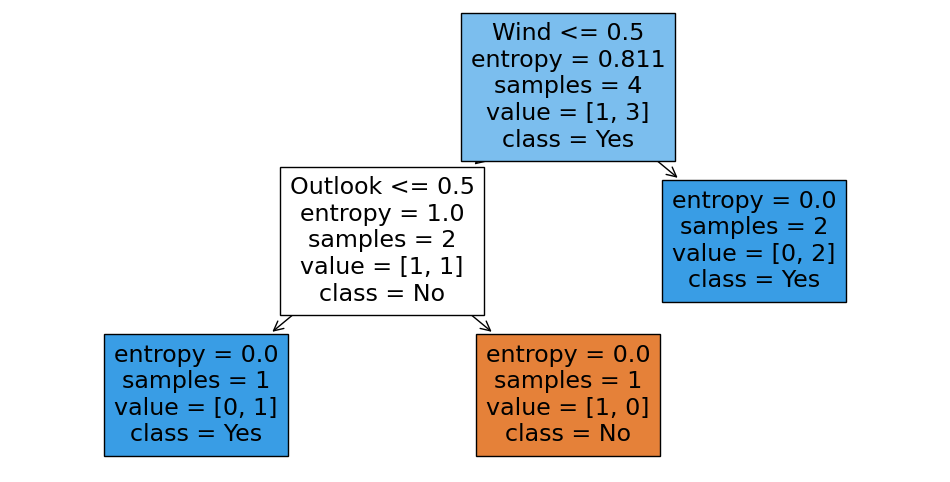

In [15]:
plt.figure(figsize=(12, 6))
plot_tree(
   model,
   feature_names = list(X.columns),
   class_names=["No","Yes"],
   filled=True
 )
plt.show()